In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

movies = pd.read_csv('data/raw/movies.csv')
details = pd.read_csv('data/raw/moviesdetails.csv')

# Rename column
movies = movies.rename(columns={'movie_id': 'id'})

# Now merge
df = pd.merge(movies, details, on='id', how='inner')

print(movies['id'].dtype)
print(details['id'].dtype)

print(movies['id'].dtype)
print(details['id'].dtype)

movies['id'].duplicated().sum()
details['id'].duplicated().sum()

# Fix column mismatch
movies = movies.rename(columns={'movie_id': 'id'})

# Merge
df = pd.merge(movies, details, on='id', how='inner')
df.info()
df.describe()
df.head()

int64
int64
int64
int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    4803 non-null   int64  
 1   title_x               4803 non-null   object 
 2   cast                  4803 non-null   object 
 3   crew                  4803 non-null   object 
 4   budget                4803 non-null   int64  
 5   genres                4803 non-null   object 
 6   homepage              1712 non-null   object 
 7   keywords              4803 non-null   object 
 8   original_language     4803 non-null   object 
 9   original_title        4803 non-null   object 
 10  overview              4800 non-null   object 
 11  popularity            4803 non-null   float64
 12  production_companies  4803 non-null   object 
 13  production_countries  4803 non-null   object 
 14  release_date          4802 non-null   object 
 1

,id,title_x,cast,crew,budget,genres,homepage,keywords,original_language,original_title,...,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title_y,vote_average,vote_count
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,...,"[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,...,"[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,...,"[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,...,"[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,...,"[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


homepage        3091
tagline          844
overview           3
runtime            2
release_date       1
dtype: int64


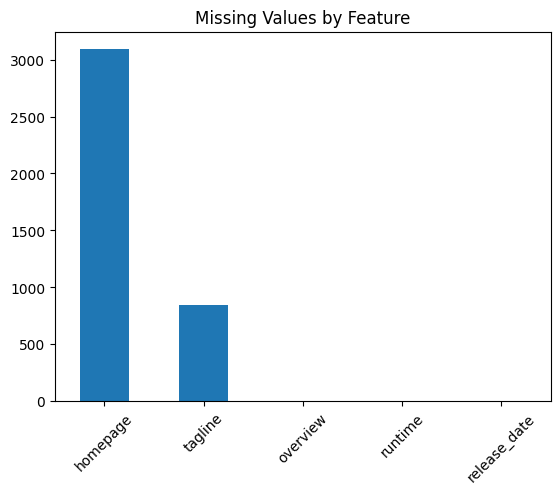

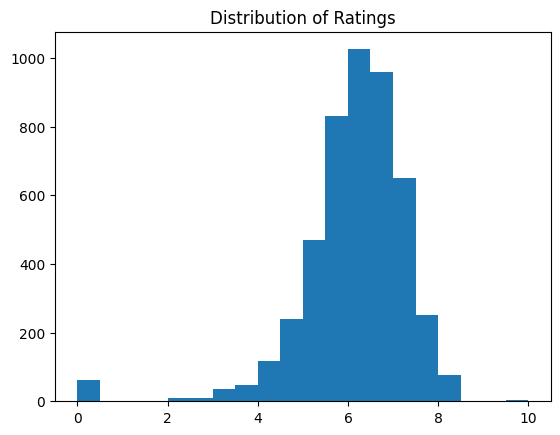

In [4]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

# Visualize missing values
missing.plot(kind='bar')
plt.title("Missing Values by Feature")
plt.xticks(rotation=45)
plt.show()

# Visualize distribution of ratings
plt.hist(df['vote_average'], bins=20)
plt.title("Distribution of Ratings")
plt.show()

In [5]:
def simplify_genre(genre):
    genre = str(genre).lower()
    
    if 'action' in genre or 'adventure' in genre:
        return 'Action'
    elif 'comedy' in genre:
        return 'Comedy'
    elif 'drama' in genre:
        return 'Drama'
    elif 'horror' in genre or 'thriller' in genre:
        return 'Horror/Thriller'
    elif 'romance' in genre:
        return 'Romance'
    elif 'animation' in genre or 'family' in genre:
        return 'Family/Animation'
    else:
        return 'Other'

df['main_genre'] = df['genres'].apply(simplify_genre)
df['main_genre'].value_counts()

main_genre
Action              1479
Drama               1338
Comedy              1333
Horror/Thriller      409
Other                164
Family/Animation      65
Romance               15
Name: count, dtype: int64

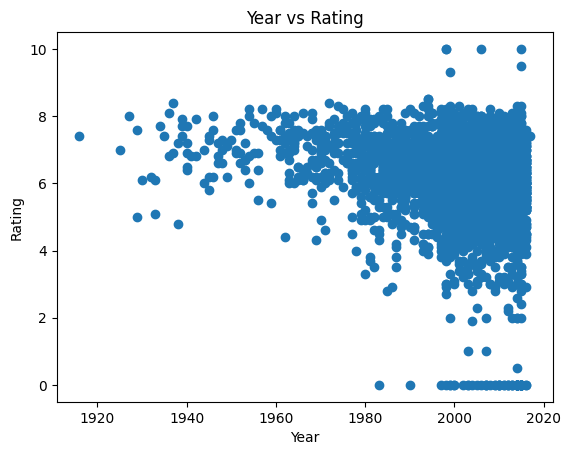

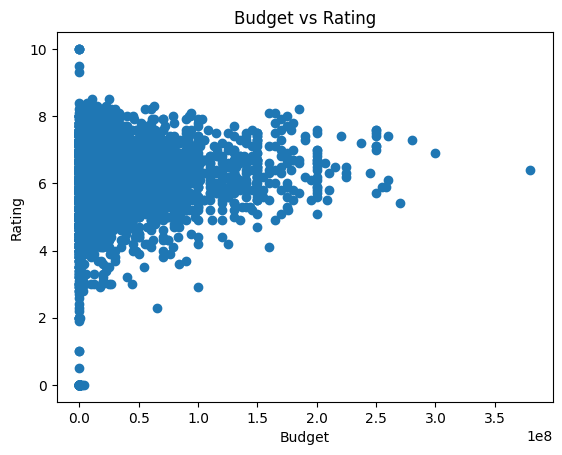

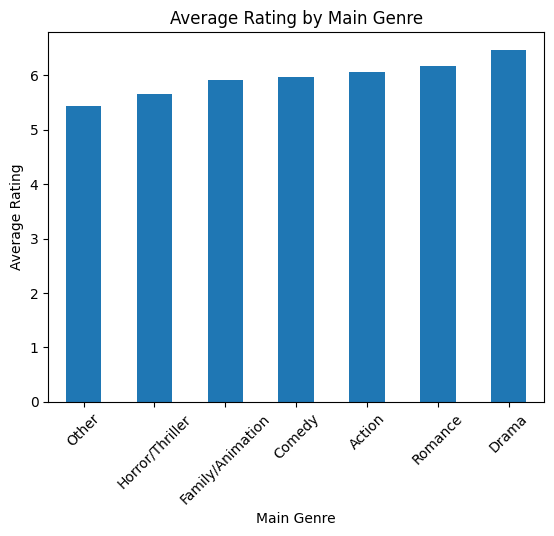

In [6]:
# Convert release_date to datetime and extract year
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

# Year vs Rating
plt.scatter(df['release_year'], df['vote_average'])
plt.xlabel("Year")
plt.ylabel("Rating")
plt.title("Year vs Rating")
plt.show()

# Budget vs Rating
plt.scatter(df['budget'], df['vote_average'])
plt.xlabel("Budget")
plt.ylabel("Rating")
plt.title("Budget vs Rating")
plt.show()

#main genre vs rating
df.groupby('main_genre')['vote_average'].mean().sort_values().plot(kind='bar')
plt.xlabel("Main Genre")
plt.ylabel("Average Rating")
plt.title("Average Rating by Main Genre")
plt.xticks(rotation=45)
plt.show()

When looking at thess three plots, specifially the first two I was actually quite shocked at how sutle of an impact the release year and budget had on the overall ratings that a movie recieved by the views. That being said the as a person who loves to watch Romance and Action movies I felt like the averages that those genres had for movies was exactly where I would put them espeically in the recent years of movie produced.

In [7]:
df['movie_age'] = 2026 - df['release_year']
df['movie_age'].head()

0    17.0
1    19.0
2    11.0
3    14.0
4    14.0
Name: movie_age, dtype: float64

This feature when in use is able to tell me how old each movies using the release year subtracted by the current year. What this feature is able to do is give me potiental trends or standards that the movie industry has made throughout the years and whether or not that change and trends are producing better movie ratings. Many people can enjoy older films and people like myself enjoy new movies. 

In [8]:
df['budget_per_min'] = df['budget'] / df['runtime']
df['budget_per_min'].head()

0    1.462963e+06
1    1.775148e+06
2    1.655405e+06
3    1.515152e+06
4    1.969697e+06
Name: budget_per_min, dtype: float64

As for this feature and what it can tell us, is that it give us a value at how much the production is using per minute of the total runtime. This feature is able to gadge a movie productions efficency, effectiveness, and overall quality of a movie. I believe this feature could tell us more than just the basic revenue feature when compared to overall movie ratings.

In [9]:
df['genre_count'] = df['genres'].apply(lambda x: len(str(x).split(',')))
df['genre_count'].head()

0    8
1    6
2    6
3    8
4    6
Name: genre_count, dtype: int64

Lastly this feature is able to tell us along with what it does is it gives the total number of genres that each movies have. When in practice can depict whether or not movies with more genres recieve higher ratings. I blieve this will be super beneficial for this overall project because if there is a big influence on this relationship many studios might take this information and us it for themselves. 

In [10]:
df[['movie_age', 'budget_per_min', 'genre_count']].head()

,movie_age,budget_per_min,genre_count
0,17.0,1.462963e+06,8
1,19.0,1.775148e+06,6
2,11.0,1.655405e+06,6
3,14.0,1.515152e+06,8
4,14.0,1.969697e+06,6


In [13]:
import time
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# -----------------------------
# Feature Engineering
# -----------------------------

# Convert release_date to datetime and extract year
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

# Create engineered features
df['movie_age'] = 2026 - df['release_year']  # Age of the movie
df['budget_per_min'] = df['budget'] / df['runtime']  # Budget efficiency per minute
df['genre_count'] = df['genres'].apply(lambda x: len(str(x).split(',')))  # Number of genres

# -----------------------------
# Handling Missing / Invalid Data
# -----------------------------

# Drop rows where key engineered features are missing
df = df.dropna(subset=['movie_age', 'budget_per_min', 'genre_count'])

# Replace invalid values in budget_per_min
df['budget_per_min'] = df['budget_per_min'].replace(0, np.nan)  # Treat 0 as missing
df['budget_per_min'] = df['budget_per_min'].replace([np.inf, -np.inf], np.nan)  # Remove infinities

# Fill missing values with median (robust to outliers)
df['budget_per_min'] = df['budget_per_min'].fillna(df['budget_per_min'].median())


In [14]:
# -----------------------------
# Feature Selection
# -----------------------------

# Define input features and target variable
features = ['movie_age', 'budget_per_min', 'genre_count',
            'budget', 'runtime', 'vote_count', 'popularity', 'revenue']

X = df[features]
y = df['vote_average']  # Target variable (movie rating)

# -----------------------------
# Train/Test Split
# -----------------------------

# Split data into 80% training and 20% testing
# random_state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [15]:
# -----------------------------
# Random Forest Model
# -----------------------------

# Initialize Random Forest (tree-based model, no scaling required)
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Track training time
start_time = time.time()

# Train model
rf.fit(X_train, y_train)

end_time = time.time()
rf_train_time = end_time - start_time

# Make predictions
rf_predictions = rf.predict(X_test)

# Evaluate model performance
mae_rf = mean_absolute_error(y_test, rf_predictions)
mse_rf = mean_squared_error(y_test, rf_predictions)

print(f"Random Forest Training Time: {rf_train_time:.2f} seconds")
print(f"Random Forest MAE: {mae_rf:.4f}")
print(f"Random Forest MSE: {mse_rf:.4f}")

Random Forest Training Time: 1.81 seconds
Random Forest MAE: 0.5688
Random Forest MSE: 0.5808


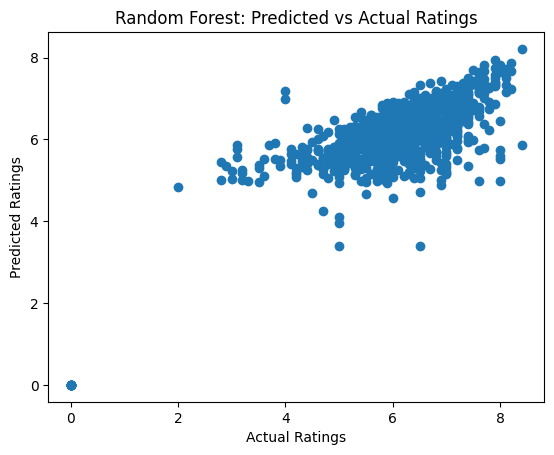

In [16]:
# Predicted vs Actual Plot (Random Forest)
plt.scatter(y_test, rf_predictions)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Random Forest: Predicted vs Actual Ratings")
plt.show()

In [21]:
# -----------------------------
# Neural Network Model
# -----------------------------

import tensorflow as tf
from tensorflow.keras import Sequential 
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler

# Feature scaling (required for Neural Networks)
scaler = StandardScaler()

# Fit scaler on training data and transform both train and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build a simple feedforward neural network
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),  # Input layer
    Dense(16, activation='relu'),  # Hidden layer
    Dense(1)  # Output layer for regression
])

# Compile model using Mean Squared Error loss
model.compile(optimizer='adam', loss='mse')

# Track training time
start_time = time.time()

# Train the model
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,  # Use part of training data for validation
    epochs=15,
    batch_size=32,
    verbose=1
)

end_time = time.time()
nn_train_time = end_time - start_time

# Make predictions
nn_predictions = model.predict(X_test_scaled).flatten()

# Evaluate model performance
mae_nn = mean_absolute_error(y_test, nn_predictions)
mse_nn = mean_squared_error(y_test, nn_predictions)

# Output results
print(f"Neural Network Training Time: {nn_train_time:.2f} seconds")
print(f"Neural Network MAE: {mae_nn:.4f}")
print(f"Neural Network MSE: {mse_nn:.4f}")

Epoch 1/15


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 17.3999 - val_loss: 6.2088
Epoch 2/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4.6929 - val_loss: 3.8634
Epoch 3/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.3777 - val_loss: 2.8867
Epoch 4/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.6071 - val_loss: 2.2068
Epoch 5/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 957us/step - loss: 2.0586 - val_loss: 1.7625
Epoch 6/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 963us/step - loss: 1.6512 - val_loss: 1.4615
Epoch 7/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 972us/step - loss: 1.3616 - val_loss: 1.2162
Epoch 8/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 983us/step - loss: 1.1665 - val_loss: 1.0738
Epoch 9/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.0452 - val_loss: 0.9813
Epoch 10/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9745 - val_loss: 0.9388
Epoch 11/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 974us/step - loss: 0.9351 - val_loss: 0.9118
Epoch 12/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 972us/step - loss: 0.9124 - val_

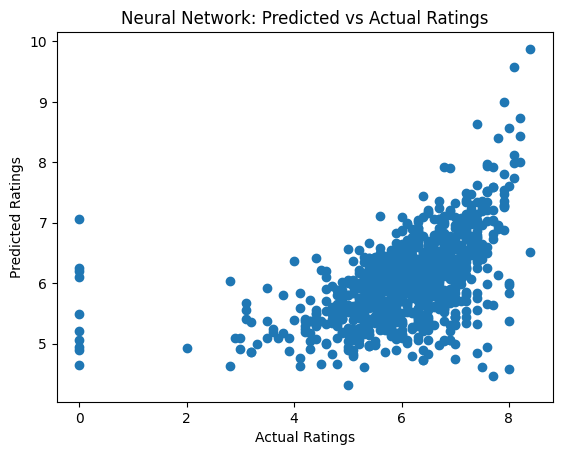

In [27]:
# Predicted vs Actual Plot (Neural Network)
plt.scatter(y_test, nn_predictions)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Neural Network: Predicted vs Actual Ratings")
plt.show()

In [28]:
# Print summary of results
results = pd.DataFrame({
    'Model': ['Random Forest', 'Neural Network'],
    'MAE': [mae_rf, mae_nn],
    'MSE': [mse_rf, mse_nn],
    'Training Time (seconds)': [rf_train_time, nn_train_time]
})

results

,Model,MAE,MSE,Training Time (seconds)
0,Random Forest,0.568814,0.580839,1.810789
1,Neural Network,0.654087,0.960411,2.457676


When looking at these results both the comparision chart along with both the perdiction plots, I think that the best preforming model is the Random Forest model when compared to the basic NN model. The MAE for the Random Forest model had a MAE of 0.568814 whereas the NN model had 0.654087. The MSE result came back 0.580839 for Random Forest and 0.960411 for the NN model. Numbers like these show that Random Forest was better suited for this prediction due to it being simpler compared to the NN model because it requires scaling and often times NN models are used for larger datasets which mine is not. Since the results cameback significantly in favor towards the Random Forest model due it's overall preformance and shorter training time I've decided to use this model for my final submission. 

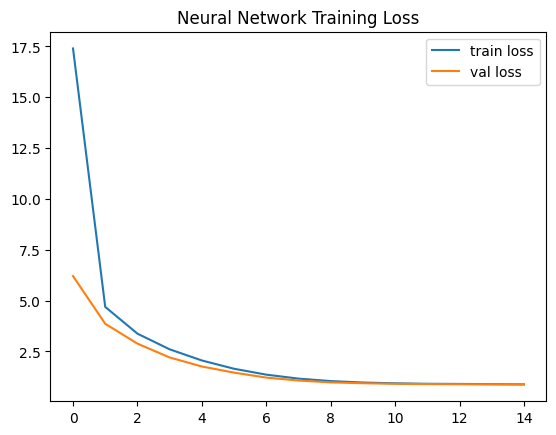

In [29]:
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.legend()
plt.title("Neural Network Training Loss")
plt.show()

After completing the intial models and seeing the results that came from both of them, I think that when it comes to building additional features for my final submission one major idea that I hav in mind is once again using the budget and revenue to find movies total profits and building upon that to get profit margins. Another engineering feature I believe will benefit this perdiction would be using vote_count and popularity to find the audience attention scores. Potientailly even a feature such as log transformations that could help fix or reduce skewed data. 
In order to produce the best model that get the best results for future movie rating perdictions, I might need to continuing to inprove the Random Forest model. This could include using hyperparameter tuning. I wanted to see if you think this is a good idea moving foward along with whether or not transforming highly skewed features would benefit this submission.

